In [1]:
# Install required packages
!pip install geopandas folium matplotlib

# Import libraries
import geopandas as gpd
import folium
from google.cloud import storage
import os

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the GeoJSON file from GCS
bucket_name = 'ycbs299'
geojson_blob_name = 'territoires-administratifs-casernes.geojson'
local_geojson_file = '/content/territoires-administratifs-casernes.geojson'
download_blob(bucket_name, geojson_blob_name, local_geojson_file)

# Load the GeoJSON file into a GeoDataFrame
gdf = gpd.read_file(local_geojson_file).to_crs("EPSG:4326")
gdf = gdf.rename(columns={"NO_CAS_ADM": "CASERNE"})

# Calculate the centroid of the GeoDataFrame to center the map
centroid = gdf.geometry.centroid
center_lat = centroid.y.mean()
center_lon = centroid.x.mean()

# Create a folium map centered on Montreal
m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='cartodbpositron')

# Add the caserne territories to the map
folium.GeoJson(
    gdf,
    style_function=lambda feature: {
        'fillColor': 'blue',  # Color for the territories
        'color': 'black',     # Border color
        'weight': 1,          # Border thickness
        'fillOpacity': 0.5    # Transparency of the fill
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=['CASERNE'],  # Display the caserne number in the tooltip
        aliases=['Caserne:']  # Label for the tooltip
    )
).add_to(m)

# Add a title to the map
title_html = '''
<h3 align="center" style="font-size:16px"><b>Caserne Territories on the Island of Montreal</b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Save the map as an HTML file
m.save('/content/caserne_territories_map.html')
print("Map saved as caserne_territories_map.html")

# Display the map in Colab
m

Downloaded territoires-administratifs-casernes.geojson to /content/territoires-administratifs-casernes.geojson


<ipython-input-1-683bf7ff01ff>:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf.geometry.centroid


Map saved as caserne_territories_map.html


In [2]:
# Install required packages
!pip install geopandas folium matplotlib pandas

# Import libraries
import geopandas as gpd
import folium
import pandas as pd
from google.cloud import storage
import os
from matplotlib import cm
import numpy as np

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the GeoJSON and CSV files from GCS
bucket_name = 'ycbs299'
geojson_blob_name = 'territoires-administratifs-casernes.geojson'
csv_blob_name = 'master_merged_adjusted_updated.csv'
local_geojson_file = '/content/territoires-administratifs-casernes.geojson'
local_csv_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, geojson_blob_name, local_geojson_file)
download_blob(bucket_name, csv_blob_name, local_csv_file)

# Load the GeoJSON file into a GeoDataFrame
gdf = gpd.read_file(local_geojson_file).to_crs("EPSG:4326")
gdf = gdf.rename(columns={"NO_CAS_ADM": "CASERNE"})

# Load the CSV file into a DataFrame
df = pd.read_csv(local_csv_file)

# Calculate the mean INCIDENT_COUNT per caserne (across all months and years)
mean_incidents = df.groupby('CASERNE')['INCIDENT_COUNT'].mean().reset_index()
mean_incidents = mean_incidents.rename(columns={'INCIDENT_COUNT': 'MEAN_INCIDENTS'})
mean_incidents['MEAN_INCIDENTS'] = mean_incidents['MEAN_INCIDENTS'].round(2)  # Round to 2 decimals

# Merge the mean incidents with the GeoDataFrame
gdf = gdf.merge(mean_incidents, on='CASERNE', how='left')

# Calculate the centroid of the GeoDataFrame to center the map
centroid = gdf.geometry.centroid
center_lat = centroid.y.mean()
center_lon = centroid.x.mean()

# Define a color scale based on MEAN_INCIDENTS
# Normalize the mean incidents to map to colors
min_incidents = gdf['MEAN_INCIDENTS'].min()
max_incidents = gdf['MEAN_INCIDENTS'].max()
def get_color(mean_incidents):
    if pd.isna(mean_incidents):
        return '#808080'  # Gray for missing data
    norm_value = (mean_incidents - min_incidents) / (max_incidents - min_incidents)
    cmap = cm.get_cmap('YlOrRd')  # Yellow to Red colormap
    color = cmap(norm_value)
    return f'#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}'

# Create a folium map centered on Montreal
m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='cartodbpositron')

# Add the caserne territories to the map with color based on MEAN_INCIDENTS
folium.GeoJson(
    gdf,
    style_function=lambda feature: {
        'fillColor': get_color(feature['properties']['MEAN_INCIDENTS']),
        'color': 'black',     # Border color
        'weight': 1,          # Border thickness
        'fillOpacity': 0.6    # Transparency of the fill
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=['CASERNE', 'MEAN_INCIDENTS'],  # Display caserne number and mean incidents
        aliases=['Caserne:', 'Mean Incidents/Month:']  # Labels for the tooltip
    )
).add_to(m)

# Add a title to the map
title_html = '''
<h3 align="center" style="font-size:16px"><b>Caserne Territories on the Island of Montreal<br>(Colored by Mean Fire Incidents per Month)</b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Add a legend for the color scale
legend_html = '''
<div style="position: fixed; bottom: 50px; right: 50px; z-index: 1000; padding: 10px; background-color: white; border: 2px solid grey; border-radius: 5px;">
<p><strong>Mean Fire Incidents per Month</strong></p>
<p><span style="color: #FFFF00;">■</span> Low ({:.1f})</p>
<p><span style="color: #FF8000;">■</span> Medium ({:.1f})</p>
<p><span style="color: #FF0000;">■</span> High ({:.1f})</p>
</div>
'''.format(min_incidents, (min_incidents + max_incidents) / 2, max_incidents)
m.get_root().html.add_child(folium.Element(legend_html))

# Save the map as an HTML file
m.save('/content/caserne_territories_incidents_map.html')
print("Map saved as caserne_territories_incidents_map.html")

# Display the map in Colab
m

Downloaded territoires-administratifs-casernes.geojson to /content/territoires-administratifs-casernes.geojson
Downloaded master_merged_adjusted_updated.csv to /content/master_merged_adjusted_updated.csv


<ipython-input-2-63ee36c5bfff>:49: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = gdf.geometry.centroid
<ipython-input-2-63ee36c5bfff>:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')  # Yellow to Red colormap


Map saved as caserne_territories_incidents_map.html


Downloaded donneesouvertes-interventions-sim (2).csv to /content/master_merged_adjusted_updated.csv


<ipython-input-1-d36c5e33e852>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Incident_Count', y='DESCRIPTION_GROUPE', data=incident_counts, palette='viridis')


Chart saved as fire_incidents_by_description_groupe.png


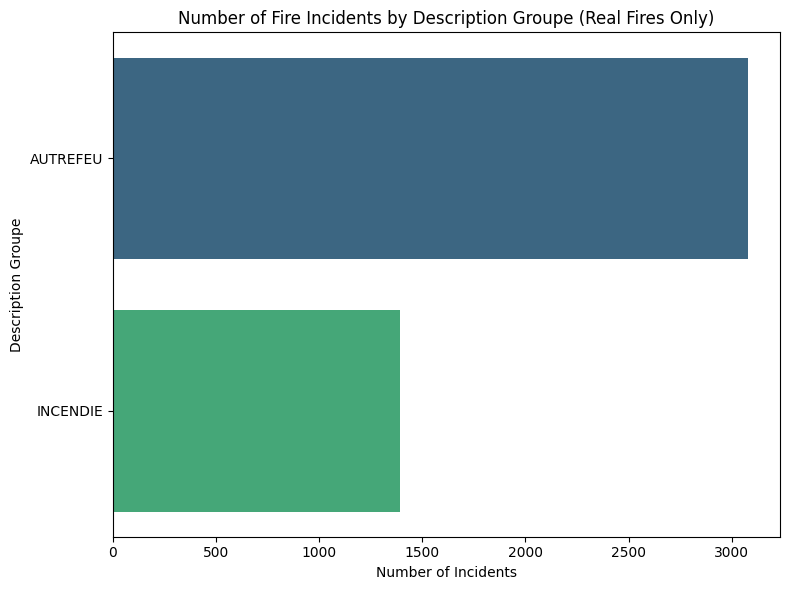

  DESCRIPTION_GROUPE  Incident_Count
0           AUTREFEU            3080
1           INCENDIE            1391


In [1]:
# Install required packages
!pip install pandas matplotlib seaborn google-cloud-storage

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import os

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the CSV file from GCS
bucket_name = 'ycbs299'
csv_blob_name = 'donneesouvertes-interventions-sim (2).csv'  # Replace with your actual file name if different
local_csv_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, csv_blob_name, local_csv_file)

# Load the CSV file into a DataFrame
df = pd.read_csv(local_csv_file)

# Filter for real fire incidents (e.g., "INCENDIE" for building fires, "AUTREFEU" for other fires)
fire_incidents = df[df['DESCRIPTION_GROUPE'].isin(['INCENDIE', 'AUTREFEU'])]

# Count incidents per DESCRIPTION_GROUPE
incident_counts = fire_incidents.groupby('DESCRIPTION_GROUPE').size().reset_index(name='Incident_Count')

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Incident_Count', y='DESCRIPTION_GROUPE', data=incident_counts, palette='viridis')
plt.title('Number of Fire Incidents by Description Groupe (Real Fires Only)')
plt.xlabel('Number of Incidents')
plt.ylabel('Description Groupe')
plt.tight_layout()

# Save the chart
plt.savefig('/content/fire_incidents_by_description_groupe.png')
print("Chart saved as fire_incidents_by_description_groupe.png")

# Display the chart in Colab
plt.show()

# Optional: Display the counts for verification
print(incident_counts)

Downloaded donneesouvertes-interventions-sim (2).csv to /content/master_merged_adjusted_updated.csv


<ipython-input-2-5396e7c3a6c6>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Incident_Count', y='DESCRIPTION_GROUPE', data=incident_counts, palette='viridis')


Chart saved as incidents_by_description_groupe.png


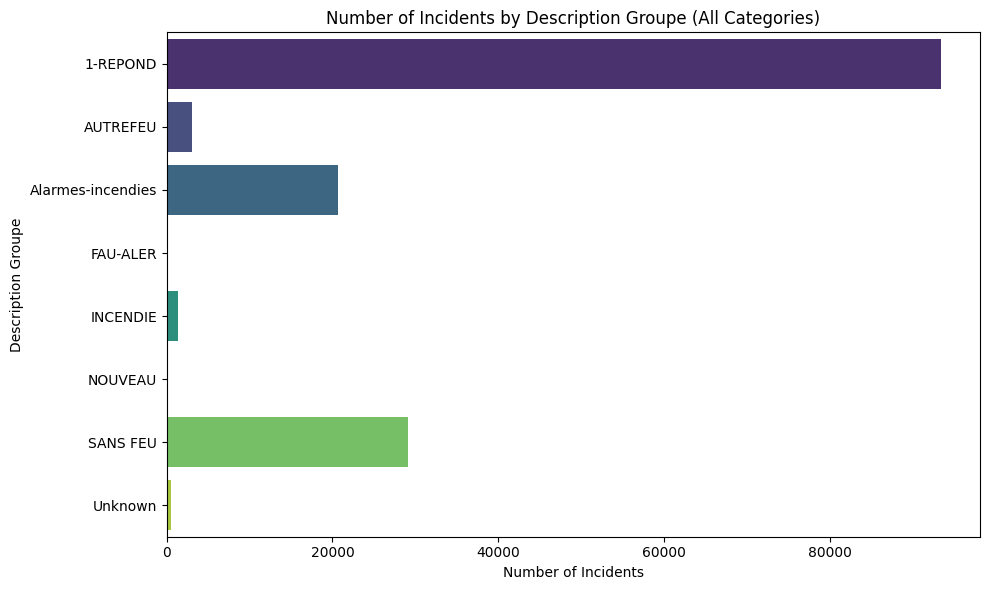

  DESCRIPTION_GROUPE  Incident_Count
0           1-REPOND           93419
1           AUTREFEU            3080
2  Alarmes-incendies           20703
3           FAU-ALER              60
4           INCENDIE            1391
5            NOUVEAU               2
6           SANS FEU           29081
7            Unknown             531


In [2]:
# Install required packages
!pip install pandas matplotlib seaborn google-cloud-storage

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import os

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the CSV file from GCS
bucket_name = 'ycbs299'
csv_blob_name = 'donneesouvertes-interventions-sim (2).csv'  # Replace with your actual file name if different
local_csv_file = '/content/master_merged_adjusted_updated.csv'
download_blob(bucket_name, csv_blob_name, local_csv_file)

# Load the CSV file into a DataFrame
df = pd.read_csv(local_csv_file)

# Replace missing or empty DESCRIPTION_GROUPE values with a placeholder (e.g., 'Unknown')
df['DESCRIPTION_GROUPE'] = df['DESCRIPTION_GROUPE'].fillna('Unknown')

# Count incidents per DESCRIPTION_GROUPE
incident_counts = df.groupby('DESCRIPTION_GROUPE').size().reset_index(name='Incident_Count')

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Incident_Count', y='DESCRIPTION_GROUPE', data=incident_counts, palette='viridis')
plt.title('Number of Incidents by Description Groupe (All Categories)')
plt.xlabel('Number of Incidents')
plt.ylabel('Description Groupe')
plt.tight_layout()

# Save the chart
plt.savefig('/content/incidents_by_description_groupe.png')
print("Chart saved as incidents_by_description_groupe.png")

# Display the chart in Colab
plt.show()

# Optional: Display the counts for verification
print(incident_counts)

Downloaded donneesouvertes-interventions-sim (2).csv to /content/donneesouvertes-interventions-sim (2).csv


<ipython-input-5-5911d4be2533>:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean_Per_Month', y='DESCRIPTION_GROUPE', data=mean_per_month, palette='viridis')


Chart saved as mean_incidents_by_description_groupe.png


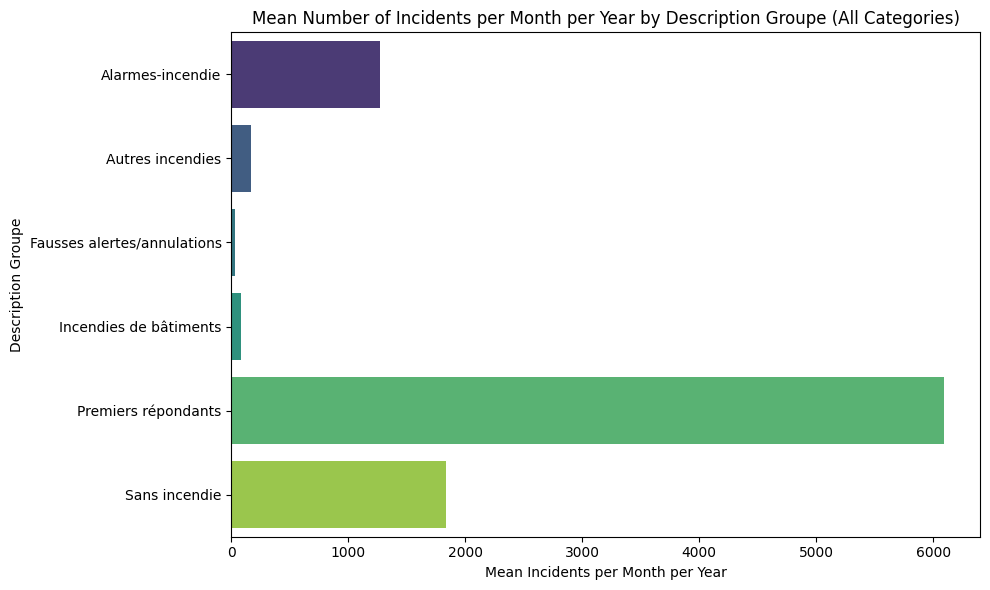

            DESCRIPTION_GROUPE  Mean_Per_Month
0             Alarmes-incendie     1274.000000
1             Autres incendies      165.458333
2  Fausses alertes/annulations       33.833333
3       Incendies de bâtiments       85.083333
4          Premiers répondants     6095.583333
5                Sans incendie     1834.583333


In [5]:
# Install required packages
!pip install pandas matplotlib seaborn google-cloud-storage

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import os

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the CSV file from GCS
bucket_name = 'ycbs299'
csv_blob_name = 'donneesouvertes-interventions-sim (2).csv'  # Updated file name
local_csv_file = '/content/donneesouvertes-interventions-sim (2).csv'
download_blob(bucket_name, csv_blob_name, local_csv_file)

# Load the CSV file into a DataFrame
df = pd.read_csv(local_csv_file)

# Map DESCRIPTION_GROUPE to original category names
category_mapping = {
    'INCENDIE': 'Incendies de bâtiments',
    'AUTREFEU': 'Autres incendies',
    'SANS FEU': 'Sans incendie',
    'Alarmes-incendies': 'Alarmes-incendie',
    '1-REPOND': 'Premiers répondants',
    'NOUVEAU': 'Fausses alertes/annulations',  # Catch-all for new/undefined
    '': 'Fausses alertes/annulations'  # Catch-all for missing/empty values
}
df['DESCRIPTION_GROUPE'] = df['DESCRIPTION_GROUPE'].fillna('').map(lambda x: category_mapping.get(x, 'Fausses alertes/annulations'))

# Extract year and month from CREATION_DATE_TIME with mixed format handling
df['CREATION_DATE_TIME'] = pd.to_datetime(df['CREATION_DATE_TIME'], format='mixed', dayfirst=True, errors='coerce')

# Drop rows where datetime parsing failed
df = df.dropna(subset=['CREATION_DATE_TIME'])

# Extract year and month
df['Year'] = df['CREATION_DATE_TIME'].dt.year
df['Month'] = df['CREATION_DATE_TIME'].dt.month

# Count incidents per DESCRIPTION_GROUPE, Year, and Month
incident_counts = df.groupby(['DESCRIPTION_GROUPE', 'Year', 'Month']).size().reset_index(name='Incident_Count')

# Calculate the mean incidents per month per year for each DESCRIPTION_GROUPE
# First, group by DESCRIPTION_GROUPE and Year to get the total incidents per year
yearly_counts = incident_counts.groupby(['DESCRIPTION_GROUPE', 'Year'])['Incident_Count'].sum().reset_index(name='Total_Incidents')

# Calculate the number of months with incidents per year for each DESCRIPTION_GROUPE
months_per_year = incident_counts.groupby(['DESCRIPTION_GROUPE', 'Year']).size().reset_index(name='Months_With_Incidents')

# Merge the counts and months to calculate the mean per month
mean_incidents = yearly_counts.merge(months_per_year, on=['DESCRIPTION_GROUPE', 'Year'])
mean_incidents['Mean_Per_Month'] = mean_incidents['Total_Incidents'] / mean_incidents['Months_With_Incidents']

# Aggregate the mean per month across years for each DESCRIPTION_GROUPE
mean_per_month = mean_incidents.groupby('DESCRIPTION_GROUPE')['Mean_Per_Month'].mean().reset_index()

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Mean_Per_Month', y='DESCRIPTION_GROUPE', data=mean_per_month, palette='viridis')
plt.title('Mean Number of Incidents per Month per Year by Description Groupe (All Categories)')
plt.xlabel('Mean Incidents per Month per Year')
plt.ylabel('Description Groupe')
plt.tight_layout()

# Save the chart
plt.savefig('/content/mean_incidents_by_description_groupe.png')
print("Chart saved as mean_incidents_by_description_groupe.png")

# Display the chart in Colab
plt.show()

# Optional: Display the mean counts for verification
print(mean_per_month)

Downloaded donneesouvertes-interventions-sim (2).csv to /content/donneesouvertes-interventions-sim (2).csv


<ipython-input-6-038ae9c51dd3>:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Mean_Per_Month', y='DESCRIPTION_GROUPE', data=mean_per_month, palette='viridis')


Chart saved as mean_incidents_by_description_groupe.png


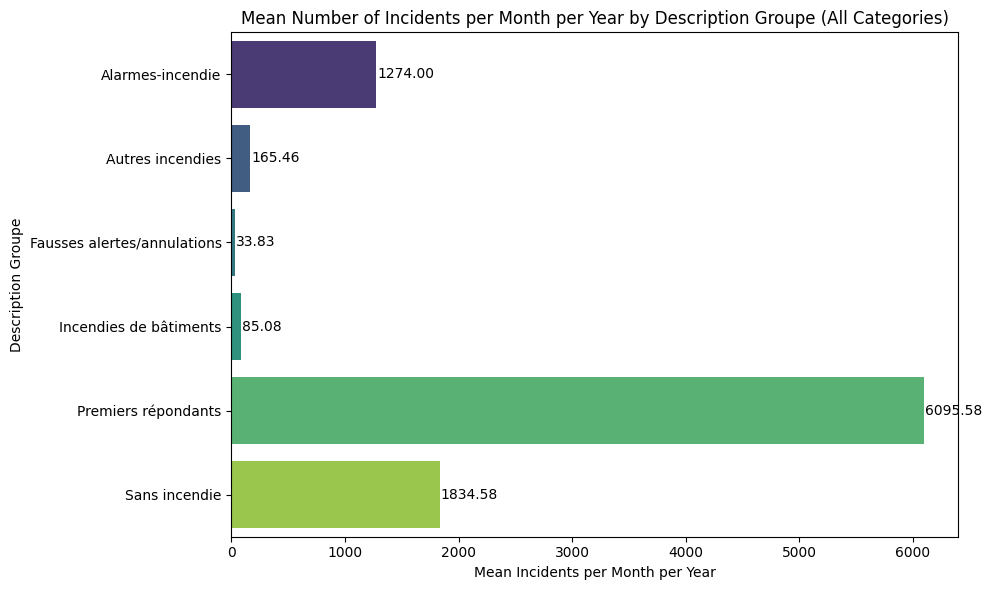

            DESCRIPTION_GROUPE  Mean_Per_Month
0             Alarmes-incendie     1274.000000
1             Autres incendies      165.458333
2  Fausses alertes/annulations       33.833333
3       Incendies de bâtiments       85.083333
4          Premiers répondants     6095.583333
5                Sans incendie     1834.583333


In [6]:
# Install required packages
!pip install pandas matplotlib seaborn google-cloud-storage

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import os

# Set up Google Cloud credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Function to download file from GCS
def download_blob(bucket_name, source_blob_name, destination_file_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)
    blob.download_to_filename(destination_file_name)
    print(f"Downloaded {source_blob_name} to {destination_file_name}")

# Download the CSV file from GCS
bucket_name = 'ycbs299'
csv_blob_name = 'donneesouvertes-interventions-sim (2).csv'  # Updated file name
local_csv_file = '/content/donneesouvertes-interventions-sim (2).csv'
download_blob(bucket_name, csv_blob_name, local_csv_file)

# Load the CSV file into a DataFrame
df = pd.read_csv(local_csv_file)

# Map DESCRIPTION_GROUPE to original category names
category_mapping = {
    'INCENDIE': 'Incendies de bâtiments',
    'AUTREFEU': 'Autres incendies',
    'SANS FEU': 'Sans incendie',
    'Alarmes-incendies': 'Alarmes-incendie',
    '1-REPOND': 'Premiers répondants',
    'NOUVEAU': 'Fausses alertes/annulations',  # Catch-all for new/undefined
    '': 'Fausses alertes/annulations'  # Catch-all for missing/empty values
}
df['DESCRIPTION_GROUPE'] = df['DESCRIPTION_GROUPE'].fillna('').map(lambda x: category_mapping.get(x, 'Fausses alertes/annulations'))

# Extract year and month from CREATION_DATE_TIME with mixed format handling
df['CREATION_DATE_TIME'] = pd.to_datetime(df['CREATION_DATE_TIME'], format='mixed', dayfirst=True, errors='coerce')

# Drop rows where datetime parsing failed
df = df.dropna(subset=['CREATION_DATE_TIME'])

# Extract year and month
df['Year'] = df['CREATION_DATE_TIME'].dt.year
df['Month'] = df['CREATION_DATE_TIME'].dt.month

# Count incidents per DESCRIPTION_GROUPE, Year, and Month
incident_counts = df.groupby(['DESCRIPTION_GROUPE', 'Year', 'Month']).size().reset_index(name='Incident_Count')

# Calculate the mean incidents per month per year for each DESCRIPTION_GROUPE
# First, group by DESCRIPTION_GROUPE and Year to get the total incidents per year
yearly_counts = incident_counts.groupby(['DESCRIPTION_GROUPE', 'Year'])['Incident_Count'].sum().reset_index(name='Total_Incidents')

# Calculate the number of months with incidents per year for each DESCRIPTION_GROUPE
months_per_year = incident_counts.groupby(['DESCRIPTION_GROUPE', 'Year']).size().reset_index(name='Months_With_Incidents')

# Merge the counts and months to calculate the mean per month
mean_incidents = yearly_counts.merge(months_per_year, on=['DESCRIPTION_GROUPE', 'Year'])
mean_incidents['Mean_Per_Month'] = mean_incidents['Total_Incidents'] / mean_incidents['Months_With_Incidents']

# Aggregate the mean per month across years for each DESCRIPTION_GROUPE
mean_per_month = mean_incidents.groupby('DESCRIPTION_GROUPE')['Mean_Per_Month'].mean().reset_index()

# Create a bar chart with labels
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Mean_Per_Month', y='DESCRIPTION_GROUPE', data=mean_per_month, palette='viridis')

# Add text labels above each bar
for i, v in enumerate(mean_per_month['Mean_Per_Month']):
    ax.text(v + 10, i, f'{v:.2f}', color='black', ha="left", va="center")

plt.title('Mean Number of Incidents per Month per Year by Description Groupe (All Categories)')
plt.xlabel('Mean Incidents per Month per Year')
plt.ylabel('Description Groupe')
plt.tight_layout()

# Save the chart
plt.savefig('/content/mean_incidents_by_description_groupe.png')
print("Chart saved as mean_incidents_by_description_groupe.png")

# Display the chart in Colab
plt.show()

# Optional: Display the mean counts for verification
print(mean_per_month)